# SHL Hiring Assessment 2026 — Grammar Scoring Engine

### Multimodal assessment of spoken English grammar

**Objective:** Predict a continuous grammar score from **0 to 5** for a 45–60 second spoken response.

This solution combines acoustic representations, speech recognition, pretrained language models, explicit grammar measurements, speaker-aware validation, and model stacking.

**Dataset:** 769 labelled training clips · 216 test clips

---

## Solution at a glance

The central idea is to treat grammar scoring as a **multimodal assessment problem** rather than a purely acoustic or text-classification task.

A spoken response contains several complementary signals:

- **How it sounds** → Whisper and WavLM representations
- **What was said** → transcript-based language-model representations
- **How grammatical it is** → CoLA, GEC, surprisal and syntactic features
- **How an examiner might judge it** → rubric-conditioned LLM representations
- **Who is speaking** → speaker embeddings for leakage-resistant validation and test-time pooling

All pretrained models are kept frozen and used as feature extractors. Regularised lightweight models are then trained on top of these representations.

## Pipeline

```
wav (16 kHz mono)
 ├─► noise guard (zero-crossing rate + dynamic range) ───────────────► unscorable clip → 0   (never fires on test)
 ├─► Whisper-large-v3 encoder (5 layers) · WavLM-large (5 layers) ───┐         "how it sounds"
 ├─► Whisper ASR ─► transcript ─┬─► RoBERTa-L / DeBERTa-v3-L / ELECTRA-L (mean-pooled layers)   "what was said"
 │                              ├─► LLM examiners (Qwen2.5-3B, Phi-3.5-mini): rubric prompt → hidden states ─┤
 │                              └─► CoLA · T5 grammar-correction · ELECTRA token-replacement · GPT-2 surprisal ·
 │                                  syntax statistics · CTC/ASR agreement  (≈ 100 interpretable rates) ───────┘
 └─► voice embedding (early WavLM layers) ─► speaker groups ─► grouped CV folds + test-time pooling
                                  │
   ~60 base regressors (Ridge / SVR / LightGBM on one or several views) ─► non-negative stacking ─► pooling ─► clip [1, 5]
```
Pretrained networks are used **frozen** as feature extractors – 732 usable clips are far too few to fine-tune them – and read out with small, strongly regularised regressors.
> **Figure 1 — End-to-end architecture.**  
> The system deliberately separates the problem into complementary views: acoustic information, transcript semantics, explicit linguistic measurements, and rubric-conditioned examiner representations. These views are combined only after their individual representations have been extracted.

## Before you run (Kaggle settings)
1. **Accelerator: GPU** (T4 ×2 or P100). **Internet: ON** (weights are downloaded from the Hugging Face hub).
2. A from-scratch run takes roughly **1.5 – 3 h** on a T4 (ASR, Whisper/WavLM features and the two LLMs dominate). Everything expensive is **cached** in `/kaggle/working/cache_v3`; if a run is interrupted, re-running resumes from the cache. After one full run you can attach the notebook's output as an *input* – the caches are re-used automatically.
3. Smoke test first: set `DEBUG_N = 24` in the config cell – every extraction step runs on a handful of clips (≈ 10 min incl. downloads) and the notebook stops before modelling. Then set `DEBUG_N = None`.
4. Every optional component is wrapped so that a failure prints `[skip] …` and the pipeline continues with the remaining views.

*Design ideas (noise clips, speaker-grouped validation, Whisper-encoder + LLM-examiner views, stacking, speaker pooling) follow what the two public top-of-leaderboard notebooks reported; all code below is a re-implementation.*

## 0. Environment & Configuration

This section defines the models, feature-extraction settings, validation protocol, and caching strategy used throughout the experiment.

The expensive neural networks are used only as **frozen feature extractors**. Their outputs are cached to disk so that modelling and stacking experiments can be repeated without recomputing the representations.

In [1]:
!pip install -q sentencepiece 2>&1 | tail -1

In [2]:
import os, re, gc, sys, json, time, glob, math, shutil, pickle, random, difflib, warnings, subprocess
from collections import Counter
from functools import partial
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import soundfile as sf, librosa, torch
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from IPython.display import display, Markdown
from scipy.optimize import nnls
from scipy.sparse.csgraph import connected_components
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import Ridge
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import lightgbm as lgb

warnings.filterwarnings("ignore")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
sns.set_theme(style="whitegrid", context="notebook")
import transformers; transformers.logging.set_verbosity_error()

# ----------------------------------------------------------------- CONFIG ------------------------------------------------------------------
SEED, SR      = 42, 16_000
DEBUG_N       = None            # e.g. 24 -> smoke-test every extraction step on a few clips, then stop before modelling. None = full run.

ASR_MODEL     = "distil-whisper/distil-large-v3"      # large-v3 encoder + 2-layer decoder: near large-v3 accuracy at a fraction of the cost
WHISPER_LAYERS = [16, 20, 24, 28, 32]                   # encoder layers (of 32) that are mean-pooled
WAVLM_ID      = "microsoft/wavlm-large"
WAVLM_LAYERS  = [12, 15, 18, 21, 24]                    # content / prosody layers (of 24)
VOICE_LAYERS  = [3, 6]                                  # early layers carry speaker identity -> used only to group clips by speaker
TEXT_ENCODERS = {   # tag -> (hub id, layers, dtype)    DeBERTa-v3 runs in fp32 (its fp16 states can overflow)
    "roberta": ("roberta-large", [12, 16, 20, 24], None),
    "electra": ("google/electra-large-discriminator", [12, 16, 20], None),
    "deberta": ("microsoft/deberta-v3-large", [16, 20, 24], torch.float32),
}
LLM_EXAMINERS = {"qwen": "Qwen/Qwen2.5-3B-Instruct", "phi": "microsoft/Phi-3.5-mini-instruct"}

# switches (set to False to skip a component / save time)
USE_WHISPER_DECODER = True      # ASR token-confidence features + decoder view
USE_TEXT_ENCODERS   = ["roberta", "electra", "deberta"]
USE_LLM             = ["qwen", "phi"]
USE_GRAMMAR_MODELS  = True      # CoLA acceptability, T5 grammar correction, ELECTRA token-replacement detection
USE_CTC             = True      # second (literal) recogniser: confidence + disagreement with Whisper

N_FOLDS, CV_REPEATS = 5, 3
POOL_LAMBDA         = 0.5       # strength of the same-speaker pooling at test time (0 = off, 1 = full averaging)
STACK_SHRINK        = 0.1       # pull of the wide stack's weights towards equal weights
ZCR_MIN, DYN_MAX    = 0.39, 10.0   # noise-guard thresholds (midpoints of the empty gaps between the two clusters, see §2)

ON_KAGGLE = Path("/kaggle/input").exists()
OUT_DIR   = Path("/kaggle/working") if ON_KAGGLE else Path(".")
CACHE_DIR = OUT_DIR / "cache_v3"; CACHE_DIR.mkdir(parents=True, exist_ok=True)
DBG       = "" if DEBUG_N is None else f"_dbg{DEBUG_N}"
N_JOBS    = max(1, os.cpu_count() or 1)
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE     = torch.float16 if DEVICE == "cuda" else torch.float32
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else "") + f" | CPUs: {N_JOBS} | debug: {DEBUG_N}")

# re-use a cache that was attached as an input (e.g. the output of an earlier run of this notebook)
if ON_KAGGLE:
    for src in glob.glob("/kaggle/input/**/cache_v3", recursive=True):
        for f in Path(src).glob("*"):
            if not (CACHE_DIR / f.name).exists(): shutil.copy(f, CACHE_DIR / f.name); print("restored from input:", f.name)

# ----------------------------------------------------------------- HELPERS -----------------------------------------------------------------
def free_gpu():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def cached(name, fn):
    """Compute fn() once and keep the result on disk (pickle); later runs load it."""
    p = CACHE_DIR / f"{name}{DBG}.pkl"
    if p.exists():
        print(f"[cache] {name}"); return pickle.load(open(p, "rb"))
    t0 = time.time(); out = fn()
    pickle.dump(out, open(p, "wb")); print(f"[done]  {name}  ({time.time() - t0:.0f}s)")
    return out

def get(name, fn):
    """Optional component: on any failure print a message and return None, so the pipeline continues without it."""
    try:
        return cached(name, fn)
    except Exception as e:
        print(f"[skip]  {name}: {type(e).__name__}: {str(e)[:220]}"); free_gpu(); return None

def hf_load(cls, name, dtype=None, **kw):
    """from_pretrained that works with both the old (torch_dtype) and the new (dtype) keyword."""
    if dtype is None: return cls.from_pretrained(name, **kw)
    try:    return cls.from_pretrained(name, dtype=dtype, **kw)
    except TypeError: return cls.from_pretrained(name, torch_dtype=dtype, **kw)

def load_audio(path):
    """float32 mono 16 kHz, untouched otherwise (no trimming / normalisation: pauses are informative and the networks expect raw audio)."""
    w, sr = sf.read(str(path), dtype="float32", always_2d=False)
    if w.ndim > 1: w = w.mean(1)
    if sr != SR: w = librosa.resample(w, orig_sr=sr, target_sr=SR)
    return w

def rmse(a, b): return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

device: cuda (Tesla T4) | CPUs: 4 | debug: None


## 1. Understanding the Dataset

Before modelling, I first examined the score distribution, audio characteristics, clip durations and train/test composition.

This analysis is important because the dataset is small enough that seemingly minor distribution differences can have a large effect on validation and leaderboard performance.

In [3]:
csv_hits = glob.glob("/kaggle/input/**/train.csv", recursive=True) or glob.glob("**/train.csv", recursive=True)
assert csv_hits, "train.csv not found - add the competition data to the notebook"
DATA_DIR = os.path.dirname(csv_hits[0]); print("DATA_DIR =", DATA_DIR)

train_df   = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df    = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

# index every wav; names repeat between the train/ and test/ folders, so each row is resolved inside its own split folder
wav_index = {}
for root, _, files in os.walk("/kaggle/input" if ON_KAGGLE else DATA_DIR):
    for f in files:
        if f.lower().endswith(".wav"): wav_index.setdefault(f, []).append(os.path.join(root, f))

def resolve(fname, split):
    cands = wav_index.get(fname, [])
    for c in cands:
        if f"/{split}/" in c.replace("\\", "/"): return c
    return cands[0] if cands else None

if DEBUG_N:
    train_df = train_df.sample(DEBUG_N, random_state=SEED).reset_index(drop=True)
    test_df  = test_df.head(max(8, DEBUG_N // 3)).reset_index(drop=True)

meta = pd.concat([train_df.assign(split="train"), test_df.assign(split="test", label=np.nan)], ignore_index=True)
meta["path"] = [resolve(f, s) for f, s in zip(meta.filename, meta.split)]
assert meta.path.notna().all(), "some audio files listed in the CSVs were not found"
assert not (set(meta.path[meta.split == "train"]) & set(meta.path[meta.split == "test"])), "a train and a test row resolve to the same file"

N_TRAIN, N = len(train_df), len(meta)
is_train   = (meta.split == "train").values
rows_test  = np.arange(N_TRAIN, N)
y_all      = train_df.label.values.astype(float)
meta["duration"] = [sf.info(p).duration for p in meta.path]
print(f"train={N_TRAIN}  test={N - N_TRAIN} | labels: {np.sort(train_df.label.unique())}")
print(meta.groupby("split").duration.describe().round(1).to_string())

DATA_DIR = /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final
train=769  test=216 | labels: [0.  1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
       count  mean  std   min   25%   50%   75%   max
split                                                
test   216.0  48.8  8.2   6.5  45.1  45.1  60.0  61.0
train  769.0  55.8  7.9  20.1  54.2  60.1  60.1  61.0


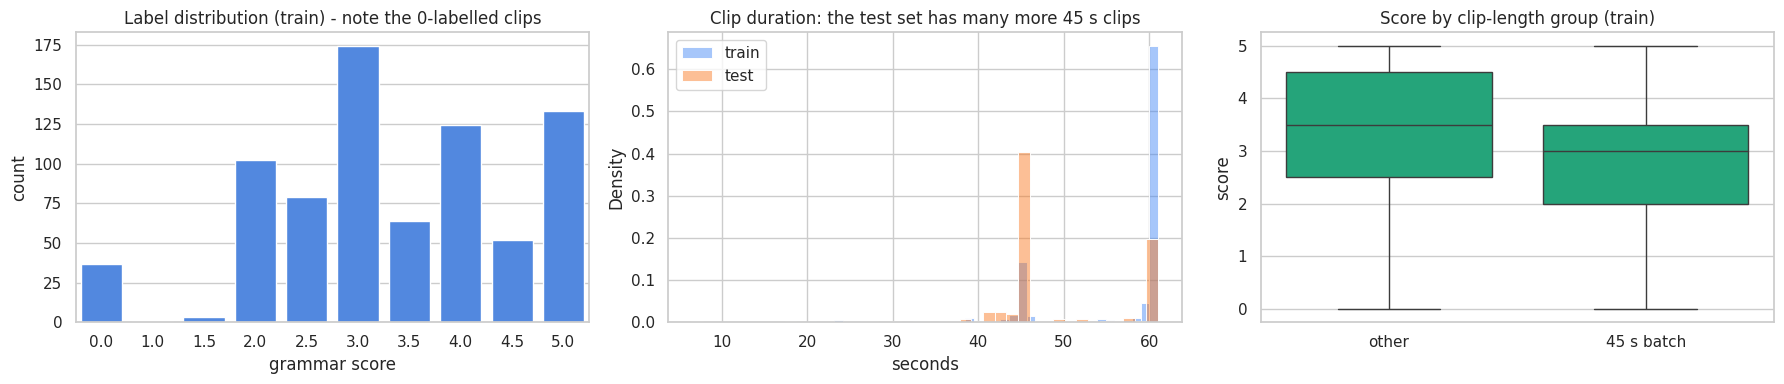

45 s batch: 14% of train clips, 47% of test clips


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(x=train_df.label, ax=ax[0], color="#3b82f6"); ax[0].set_title("Label distribution (train) - note the 0-labelled clips"); ax[0].set_xlabel("grammar score")
for s, c in (("train", "#3b82f6"), ("test", "#f97316")):
    sns.histplot(meta.duration[meta.split == s], bins=40, ax=ax[1], color=c, label=s, stat="density", alpha=.45)
ax[1].set_title("Clip duration: the test set has many more 45 s clips"); ax[1].set_xlabel("seconds"); ax[1].legend()
b45 = (meta.duration[:N_TRAIN] - 45.06).abs().values < 0.1
sns.boxplot(x=np.where(b45, "45 s batch", "other"), y=y_all, ax=ax[2], color="#10b981"); ax[2].set_title("Score by clip-length group (train)"); ax[2].set_ylabel("score")
plt.tight_layout(); plt.show()
print(f"45 s batch: {b45.mean():.0%} of train clips, {((meta.duration[N_TRAIN:] - 45.06).abs() < 0.1).mean():.0%} of test clips")

> **Figure 2 — Training-label distribution.**  
> The target is continuous on the 0–5 rubric, but the available labels are concentrated around the middle of the scale. The small number of extreme examples makes accurate prediction at the boundaries substantially harder than prediction near the mean.

## 2. Audio Quality Analysis & Noise Guard

The first important observation is that the 0-labelled recordings are not ordinary low-grammar examples. They correspond to heavily corrupted/noise-dominated recordings.

Treating these clips as normal regression targets would encourage the model to learn an undesirable shortcut:

**poor audio quality → low grammar score**

Instead, the pipeline separates the problem into:

1. **Scorable speech** → predict a grammar score in the range 1–5.
2. **Clearly corrupted audio** → identify with a simple deterministic noise guard and assign 0.

The guard uses audio statistics rather than a learned classifier, keeping this special case interpretable and avoiding additional model complexity.

wave stats:   0%|          | 0/985 [00:00<?, ?it/s]

[done]  wave_stats  (44s)
noise guard: flags 37 train clips | label-0 clips: 37 | agreement on train: 100.0%
noise guard flags 0 of 216 test clips


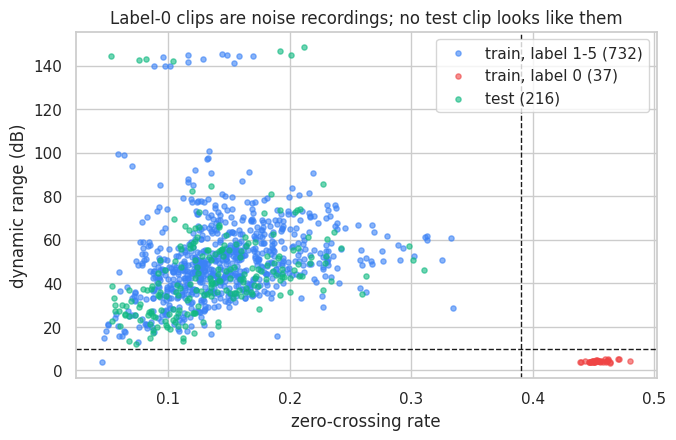

regressors are trained on 732 clips (labels 1 - 5); predict-the-mean RMSE = 1.014


In [5]:
def wave_stats(path):
    """Noise-guard inputs + pause statistics for one clip (everything is a rate / ratio, independent of clip length)."""
    w = load_audio(path); dur = len(w) / SR
    rms = librosa.feature.rms(y=w, frame_length=400, hop_length=160)[0]; db = 20 * np.log10(rms + 1e-8)
    out = dict(dyn_range=np.percentile(db, 95) - np.percentile(db, 5), zcr=librosa.feature.zero_crossing_rate(w).mean())
    voiced = db > (np.percentile(db, 95) - 35)                                  # speech = within 35 dB of the clip's loud level
    edges = np.diff(np.concatenate([[0], voiced.astype(int), [0]]))
    st, en = np.where(edges == 1)[0], np.where(edges == -1)[0]
    runs = (en - st) / 100.0; gaps = (st[1:] - en[:-1]) / 100.0 if len(st) > 1 else np.array([0.0]); pauses = gaps[gaps > 0.3]
    out.update(voiced_frac=voiced.mean(), pauses_per_s=len(pauses) / dur, long_pauses_per_s=(gaps > 1.0).sum() / dur,
               mean_pause=pauses.mean() if len(pauses) else 0.0, max_pause=gaps.max(), mean_run=runs.mean() if len(runs) else 0.0)
    return {k: float(v) for k, v in out.items()}

wstats = cached("wave_stats", lambda: pd.DataFrame(Parallel(n_jobs=N_JOBS)(delayed(wave_stats)(p) for p in tqdm(meta.path, desc="wave stats"))))

is_noise = ((wstats.zcr > ZCR_MIN) & (wstats.dyn_range < DYN_MAX)).values
zero_lab = y_all == 0
print(f"noise guard: flags {is_noise[:N_TRAIN].sum()} train clips | label-0 clips: {zero_lab.sum()} | agreement on train: {(is_noise[:N_TRAIN] == zero_lab).mean():.1%}")
print(f"noise guard flags {is_noise[N_TRAIN:].sum()} of {N - N_TRAIN} test clips")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for m, c, l in ((is_train & ~np.r_[zero_lab, np.zeros(N - N_TRAIN, bool)], "#3b82f6", "train, label 1-5"), (np.r_[zero_lab, np.zeros(N - N_TRAIN, bool)], "#ef4444", "train, label 0"), (~is_train, "#10b981", "test")):
    ax.scatter(wstats.zcr[m], wstats.dyn_range[m], s=14, alpha=.6, c=c, label=f"{l} ({m.sum()})")
ax.axvline(ZCR_MIN, color="k", ls="--", lw=1); ax.axhline(DYN_MAX, color="k", ls="--", lw=1)
ax.set(xlabel="zero-crossing rate", ylabel="dynamic range (dB)", title="Label-0 clips are noise recordings; no test clip looks like them"); ax.legend(); plt.show()

graded = y_all > 0                                  # clips the grammar regressors may learn from (label 1 - 5)
rows_g = np.where(graded)[0]; y = y_all[graded]
print(f"regressors are trained on {graded.sum()} clips (labels {y.min():g} - {y.max():g}); predict-the-mean RMSE = {y.std():.3f}")

## 3. Automatic Speech Recognition

Grammar is fundamentally expressed through language, so the spoken responses are first converted into transcripts using **Distil-Whisper large-v3**.

The transcript is subsequently used by several independent language models and grammar-analysis components.

Whisper is also used as a feature extractor: its encoder states provide a representation of the acoustic/linguistic content of the response, while decoder-side information provides additional ASR confidence signals.

### Why use both audio and text?

A transcript alone can lose information about pronunciation, hesitation and delivery. Conversely, an acoustic embedding does not directly expose the grammatical structure of the words.

The final system therefore retains both views.

In [6]:
_WHISPER = {}
def get_whisper():
    if not _WHISPER:
        from transformers import WhisperForConditionalGeneration, WhisperProcessor
        _WHISPER["proc"]  = WhisperProcessor.from_pretrained(ASR_MODEL)
        _WHISPER["model"] = hf_load(WhisperForConditionalGeneration, ASR_MODEL, DTYPE).to(DEVICE).eval()
    return _WHISPER["model"], _WHISPER["proc"]

def drop_whisper(): _WHISPER.clear(); free_gpu()

def transcribe_all(batch_size=6):
    path = CACHE_DIR / f"transcripts{DBG}.jsonl"; done = {}
    if path.exists():
        for line in open(path, encoding="utf-8"):
            if line.strip(): r = json.loads(line); done[(r["split"], r["filename"])] = r
    todo = [(s, f, p) for s, f, p in zip(meta.split, meta.filename, meta.path) if (s, f) not in done]
    if todo:
        from transformers import pipeline
        model, proc = get_whisper()
        asr = pipeline("automatic-speech-recognition", model=model, tokenizer=proc.tokenizer, feature_extractor=proc.feature_extractor, device=DEVICE)
        t0 = time.time()
        with open(path, "a", encoding="utf-8") as fo:
            for i in tqdm(range(0, len(todo), batch_size), desc="Whisper ASR"):
                batch = todo[i:i + batch_size]; waves = [load_audio(p) for _, _, p in batch]
                outs = asr([{"raw": w, "sampling_rate": SR} for w in waves], chunk_length_s=30, batch_size=batch_size, return_timestamps=True)
                for (s, f, _), o, w in zip(batch, outs, waves):
                    r = {"split": s, "filename": f, "text": o["text"].strip(), "duration": len(w) / SR}
                    fo.write(json.dumps(r) + "\n"); done[(s, f)] = r
                fo.flush()
        print(f"transcribed {len(todo)} clips in {time.time() - t0:.0f}s"); del asr
    return pd.DataFrame([done[(s, f)] for s, f in zip(meta.split, meta.filename)])

_LOOP = re.compile(r"(\b\w+(?:\W+\w+){0,5}?)(?:\W+\1\b){3,}", flags=re.IGNORECASE)
def collapse_loops(t): return _LOOP.sub(r"\1", t)          # a 1-6 word phrase repeated 4+ times in a row -> once

asr_df = transcribe_all()
meta["raw_text"] = asr_df.text.fillna("").astype(str).values
meta["text"]     = meta.raw_text.apply(collapse_loops)
texts = meta.text.tolist()
print(f"loops collapsed in {(meta.text != meta.raw_text).sum()} clips | median words: train {meta.text[is_train].str.split().str.len().median():.0f}, test {meta.text[~is_train].str.split().str.len().median():.0f}")
for i in [0, 1, 2]: print(f"[{meta.filename[i]} | label={meta.label[i]}] {texts[i][:300]}\n")

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/539 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/4.25k [00:00<?, ?B/s]

Whisper ASR:   0%|          | 0/165 [00:00<?, ?it/s]

transcribed 985 clips in 1641s
loops collapsed in 7 clips | median words: train 102, test 96
[audio_192.wav | label=3.0] Well, the playground is very, very beautiful and fun. There are play tools like the miracle round, the swing. The students usually enjoy the swing. It has to be like, it's more like a game of pair. Because once it's a minute and the other person we'll have to push, then the may go around. They just 

[audio_436.wav | label=3.0] the scene of a school playground our playground looks like a very big playground having a more more greenery trees in which we students like to garden a more trees to have a fresh year and all having a fresh oxygen this in the playground these trees gives a very greenery view which will a very pleas

[audio_447.wav | label=3.5] My favorite place to visit is the beach. I love the sound of the webs crashing against the shore. The feeling of the sand between my toys and the smell of the salt water. I love the fact that there is always something t

## 4. Building Multiple Views of Each Response

A single pretrained representation is unlikely to capture every aspect of human grammar assessment.

Instead, each response is represented through several complementary views.

### 4.1 Acoustic / speech representations

**Whisper** and **WavLM** provide hidden representations of the spoken signal. Different network depths are retained because intermediate layers can encode different mixtures of phonetic, lexical, prosodic and higher-level information.

The representations are mean-pooled over valid speech regions to obtain fixed-length vectors.

### 4.2 Transcript representations

The Whisper transcript is passed through several pretrained language encoders:

- RoBERTa-large
- DeBERTa-v3-large
- ELECTRA-large

Different layers are retained because grammar-related information does not necessarily peak at the final layer of a pretrained encoder.

### 4.3 Rubric-conditioned examiner representations

Two instruction-tuned language models — Qwen2.5-3B and Phi-3.5-mini — are prompted using the grammar-scoring task itself.

Rather than relying only on their generated score, their hidden states are extracted and given to a supervised regression model.

This allows the pretrained language model to provide a rich **"examiner-like" representation**, while the regression layer learns how that representation maps to the competition's numerical labels.

In [7]:
def _windows(w):
    """Non-overlapping 30 s windows (Whisper's native length); a trailing sliver under 0.5 s is dropped."""
    wins = [w[s:s + 30 * SR] for s in range(0, len(w), 30 * SR)]
    return [x for x in wins if len(x) >= SR // 2] or [w]

def whisper_encoder_layers():
    model, proc = get_whisper(); enc, fe = model.model.encoder, proc.feature_extractor
    out = np.zeros((N, len(WHISPER_LAYERS), enc.config.d_model), dtype=np.float32)
    for i in tqdm(range(N), desc="Whisper encoder"):
        wins = _windows(load_audio(meta.path[i]))
        x = fe(wins, sampling_rate=SR, return_tensors="pt").input_features.to(DEVICE, DTYPE)
        with torch.no_grad(): hs = enc(x, output_hidden_states=True).hidden_states
        n_valid = [max(1, min(1500, len(w) // 320)) for w in wins]                 # one encoder frame per 320 samples; padding excluded
        for li, L in enumerate(WHISPER_LAYERS):
            tot = sum(hs[L][j, :nf].float().sum(0) for j, nf in enumerate(n_valid))
            out[i, li] = (tot / sum(n_valid)).cpu().numpy()
    return out

def whisper_decoder_view():
    """Greedy-decode each window, then read the decoder: mean state of decoder layer 1 and token log-probabilities."""
    model, proc = get_whisper(); special = torch.tensor(proc.tokenizer.all_special_ids, device=DEVICE)
    dec1 = np.zeros((N, model.config.d_model), dtype=np.float32); conf = []
    for i in tqdm(range(N), desc="Whisper decoder"):
        w = load_audio(meta.path[i])
        x = proc.feature_extractor(_windows(w), sampling_rate=SR, return_tensors="pt").input_features.to(DEVICE, DTYPE)
        with torch.no_grad():
            seq = model.generate(x, language="en", task="transcribe", return_timestamps=False, max_new_tokens=220, do_sample=False, num_beams=1)
            out = model(input_features=x, decoder_input_ids=seq[:, :-1], output_hidden_states=True)
        logp = torch.log_softmax(out.logits.float(), -1).gather(-1, seq[:, 1:].unsqueeze(-1)).squeeze(-1)
        mask = ~torch.isin(seq[:, 1:], special)                                        # real word-piece tokens only
        lp = logp[mask].cpu().numpy(); lp = lp if len(lp) else np.array([-5.0])
        dec1[i] = ((out.decoder_hidden_states[1].float() * mask.unsqueeze(-1)).sum((0, 1)) / max(int(mask.sum()), 1)).cpu().numpy()
        conf.append(dict(asr_lp_mean=lp.mean(), asr_lp_p10=np.percentile(lp, 10), asr_lp_min=lp.min(), asr_lp_std=lp.std(),
                         asr_low_conf=(lp < -1.0).mean(), asr_very_low_conf=(lp < -2.5).mean(), asr_ntok_per_s=len(lp) / (len(w) / SR)))
    return dec1, pd.DataFrame(conf)

def wavlm_views():
    from transformers import AutoFeatureExtractor, AutoModel
    fe = AutoFeatureExtractor.from_pretrained(WAVLM_ID); mod = hf_load(AutoModel, WAVLM_ID, DTYPE).to(DEVICE).eval(); H = mod.config.hidden_size
    layers = np.zeros((N, len(WAVLM_LAYERS), H), np.float32); voice = np.zeros((N, 2 * H * len(VOICE_LAYERS)), np.float32)
    for i in tqdm(range(N), desc="WavLM"):
        x = fe(load_audio(meta.path[i]), sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE, DTYPE)
        with torch.no_grad(): hs = mod(x, output_hidden_states=True).hidden_states
        for li, L in enumerate(WAVLM_LAYERS): layers[i, li] = hs[L][0].float().mean(0).cpu().numpy()
        voice[i] = torch.cat([torch.cat([hs[L][0].float().mean(0), hs[L][0].float().std(0)]) for L in VOICE_LAYERS]).cpu().numpy()
    del mod; free_gpu()
    return layers, voice

whisper_enc = get("whisper_enc", whisper_encoder_layers)
dec_out     = get("whisper_dec", whisper_decoder_view) if USE_WHISPER_DECODER else None
drop_whisper()
wavlm_out   = get("wavlm", wavlm_views)
print("whisper encoder:", None if whisper_enc is None else whisper_enc.shape, "| decoder:", None if dec_out is None else dec_out[0].shape,
      "| wavlm:", None if wavlm_out is None else wavlm_out[0].shape)

Whisper encoder:   0%|          | 0/985 [00:00<?, ?it/s]

[done]  whisper_enc  (326s)


Whisper decoder:   0%|          | 0/985 [00:00<?, ?it/s]

[done]  whisper_dec  (941s)


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.26GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

WavLM:   0%|          | 0/985 [00:00<?, ?it/s]

[done]  wavlm  (899s)
whisper encoder: (985, 5, 1280) | decoder: (985, 1280) | wavlm: (985, 5, 1024)


### 4.2 Reading – transcript encoders
Three pretrained text encoders read the transcript; token states of selected layers are mean-pooled. **RoBERTa-large** (masked LM, syntax-sensitive upper-middle layers), **DeBERTa-v3-large** (a stronger encoder with a different pre-training objective) and **ELECTRA-large discriminator** (trained to spot tokens that do not belong – close to spotting errors).

### 4.3 Examining – small LLMs prompted with the rubric
Two instruction-tuned LLMs are used as *feature extractors*, not scorers. For each transcript we keep (i) the **prompted state** – the hidden state at the position where the model would answer "which score does this transcript deserve under the rubric?", (ii) the **pooled state** over the transcript alone, and (iii) the model's zero-shot probabilities for the scores 1…5. The zero-shot score on its own is weak, but a ridge read-out of the hidden states is among the best single views.

In [8]:
def mean_pooled_layers(model_name, layers, txts, dtype=None, max_length=384, bs=8):
    from transformers import AutoModel, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(model_name); mod = hf_load(AutoModel, model_name, dtype or DTYPE).to(DEVICE).eval()
    out = np.zeros((len(txts), len(layers), mod.config.hidden_size), np.float32)
    for i in tqdm(range(0, len(txts), bs), desc=model_name.split("/")[-1]):
        b = tok([t if t.strip() else "." for t in txts[i:i + bs]], return_tensors="pt", padding=True, truncation=True, max_length=max_length).to(DEVICE)
        with torch.no_grad(): hs = mod(**b, output_hidden_states=True).hidden_states
        m = b.attention_mask.unsqueeze(-1).float()
        for li, L in enumerate(layers): out[i:i + bs, li] = ((hs[L].float() * m).sum(1) / m.sum(1)).cpu().numpy()
    del mod; free_gpu()
    return out

text_enc = {}
for tag in USE_TEXT_ENCODERS:
    mname, layers_, dt = TEXT_ENCODERS[tag]
    arr = get(f"text_{tag}", lambda m=mname, l=layers_, d=dt: mean_pooled_layers(m, l, texts, d))
    if arr is not None: text_enc[tag] = arr
print({k: v.shape for k, v in text_enc.items()})

# --------------------------------------------------------------- LLM examiners ---------------------------------------------------------------
RUBRIC_PROMPT = """You are an expert examiner of spoken English. Below is an automatic transcript of a 45-60 second spoken response. The transcript may lack punctuation; judge only the speaker's grammar.

Grammar score rubric:
1 - Struggles with sentence structure and syntax; limited control over even simple, memorised patterns.
2 - Limited understanding of sentence structure; consistent basic grammatical mistakes; may leave sentences incomplete.
3 - Decent grasp of sentence structure but makes errors in grammatical structure, or vice versa.
4 - Strong understanding of sentence structure and syntax; good control of grammar; occasional minor errors.
5 - High grammatical accuracy and adept control of complex grammar; seldom makes noticeable mistakes.

Transcript:
\"\"\"{text}\"\"\"

Give the grammar score as a single digit from 1 to 5."""

def llm_examiner(model_id, txts, max_words=400):
    from transformers import AutoModelForCausalLM, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(model_id); tok.padding_side = "left"
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    model = hf_load(AutoModelForCausalLM, model_id, DTYPE).to(DEVICE).eval()
    L, H = model.config.num_hidden_layers, model.config.hidden_size
    layers = sorted({L // 3, L // 2, (2 * L) // 3, (5 * L) // 6, L})
    digit_ids = [tok.encode(str(d), add_special_tokens=False)[-1] for d in range(1, 6)]
    txts = [" ".join(t.split()[:max_words]) or "." for t in txts]
    prompt = lambda t: tok.apply_chat_template([{"role": "user", "content": RUBRIC_PROMPT.format(text=t)}], tokenize=False, add_generation_prompt=True) + "Grammar score: "
    n = len(txts); last = np.zeros((n, len(layers), H), np.float32); pooled = np.zeros_like(last); zs = np.zeros((n, 6), np.float32)
    order = np.argsort([len(t) for t in txts]); batches, i = [], 0
    while i < n:                                      # short transcripts four at a time, long ones singly (memory)
        bs = 4 if len(txts[order[min(i + 3, n - 1)]]) < 700 else (2 if len(txts[order[min(i + 1, n - 1)]]) < 1100 else 1)
        batches.append(order[i:i + bs]); i += bs
    for idx in tqdm(batches, desc=model_id.split("/")[-1]):
        free_gpu()
        b = tok([prompt(txts[j]) for j in idx], return_tensors="pt", padding=True, truncation=True, max_length=1200).to(DEVICE)
        with torch.no_grad(): o = model(**b, output_hidden_states=True)
        for li, Ly in enumerate(layers): last[idx, li] = o.hidden_states[Ly][:, -1].float().cpu().numpy()
        p = torch.softmax(o.logits[:, -1].float()[:, digit_ids], -1).cpu().numpy(); zs[idx, :5] = p; zs[idx, 5] = p @ np.arange(1, 6)
        del o
        b = tok([txts[j] for j in idx], return_tensors="pt", padding=True, truncation=True, max_length=512).to(DEVICE)
        with torch.no_grad(): o = model(**b, output_hidden_states=True)
        m = b.attention_mask.unsqueeze(-1).float()
        for li, Ly in enumerate(layers): pooled[idx, li] = ((o.hidden_states[Ly].float() * m).sum(1) / m.sum(1)).cpu().numpy()
        del o
    del model; free_gpu()
    return last, pooled, zs, layers

llm_out = {}
for tag in USE_LLM:
    r = get(f"llm_{tag}", lambda t=tag: llm_examiner(LLM_EXAMINERS[t], texts))
    if r is not None: llm_out[tag] = r
print({k: (v[0].shape, v[3]) for k, v in llm_out.items()})

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

Phi-3.5-mini-instruct:   0%|          | 0/280 [00:00<?, ?it/s]

[done]  llm_phi  (396s)
{'qwen': ((985, 5, 2048), [12, 18, 24, 30, 36]), 'phi': ((985, 5, 3072), [10, 16, 21, 26, 32])}


### 4.4 Explicit Grammar Measurements

Neural embeddings are powerful but difficult to interpret. I therefore complement them with explicit linguistic measurements designed to capture different aspects of grammatical competence.

The feature set includes:

| Feature family | What it measures |
|---|---|
| **CoLA** | Sentence acceptability |
| **T5 GEC** | Amount of grammar correction required |
| **ELECTRA** | Token-level linguistic anomalies |
| **GPT-2 surprisal** | How unexpected each token is under a language model |
| **Syntax statistics** | POS structure, clauses, dependency depth and related patterns |
| **Lexical features** | Vocabulary richness and usage patterns |
| **ASR agreement** | Consistency between independent speech recognisers |
| **Fluency rates** | Pauses, speech runs and speaking-rate characteristics |

Importantly, count-based features are converted into **rates or normalized statistics** wherever possible so that differences in recording length do not directly become model features.

In [9]:
_WORD = re.compile(r"[a-z']+")
FILLERS = {"um", "uh", "er", "ah", "hmm", "umm", "uhm", "erm", "like", "well", "so"}
SUBORD  = {"because", "although", "though", "which", "that", "while", "if", "when", "who", "whose", "whereas", "since", "unless", "until", "however", "therefore"}
COORD   = {"and", "but", "or", "yet"}
AUX     = {"is", "are", "was", "were", "am", "be", "been", "being", "have", "has", "had", "do", "does", "did", "will", "would", "can", "could", "should", "may", "might", "must"}
words = lambda t: _WORD.findall(t.lower())

def segments(text, max_words=40):
    """Sentences of a transcript; over-long unpunctuated runs are cut into windows of <= max_words words."""
    segs = []
    for sent in re.split(r"(?<=[.!?])\s+", text.strip()):
        toks = sent.split()
        for s in range(0, len(toks), max_words): segs.append(" ".join(toks[s:s + max_words]))
    return [s for s in segs if s] or [""]

SEGS = [segments(t) for t in texts]
FLAT = [(i, s) for i, ss in enumerate(SEGS) for s in ss]                         # (clip index, sentence)
CLIP_OF = np.array([i for i, _ in FLAT]); SEG_W = np.array([max(len(words(s)), 1) for _, s in FLAT])

def lexical_rates():
    rows = []
    for i, t in enumerate(texts):
        w = words(t); n = max(len(w), 1); bi = list(zip(w, w[1:])); sl = np.array([max(len(words(s)), 1) for s in SEGS[i]]); cnt = Counter(w)
        rows.append(dict(ttr_60=len(set(w[:60])) / max(len(w[:60]), 1), mean_word_len=float(np.mean([len(x) for x in w])) if w else 0.0,
                         long_word_rate=sum(len(x) > 6 for x in w) / n, words_per_segment=n / len(SEGS[i]), seg_len_std=float(sl.std()), short_seg_rate=float((sl < 4).mean()),
                         immediate_repeat_rate=sum(a == b for a, b in bi) / n, bigram_repeat_rate=1 - len(set(bi)) / max(len(bi), 1),
                         filler_rate=sum(x in FILLERS for x in w) / n, subordinator_rate=sum(x in SUBORD for x in w) / n, coord_rate=sum(x in COORD for x in w) / n,
                         aux_rate=sum(x in AUX for x in w) / n, i_rate=cnt["i"] / n, contraction_rate=sum("'" in x for x in w) / n,
                         comma_rate=t.count(",") / n, dash_rate=(t.count("-") + t.count("...")) / n))
    return pd.DataFrame(rows)

def gpt2_feats():
    from transformers import AutoModelForCausalLM, AutoTokenizer
    tok = AutoTokenizer.from_pretrained("gpt2-medium"); mod = AutoModelForCausalLM.from_pretrained("gpt2-medium").to(DEVICE).eval(); rows = []
    for t in tqdm(texts, desc="GPT-2"):
        ids = tok(tok.bos_token + t, return_tensors="pt", truncation=True, max_length=512).input_ids.to(DEVICE)
        if ids.shape[1] < 3: rows.append(dict(lm_nll=10.0, lm_nll_p90=10.0, lm_nll_med=10.0, lm_frac_hi=1.0)); continue
        with torch.no_grad(): lg = mod(ids).logits[0, :-1].float()
        nll = torch.nn.functional.cross_entropy(lg, ids[0, 1:], reduction="none").cpu().numpy()
        rows.append(dict(lm_nll=nll.mean(), lm_nll_p90=np.percentile(nll, 90), lm_nll_med=np.median(nll), lm_frac_hi=(nll > 8).mean()))
    del mod; free_gpu(); return pd.DataFrame(rows)

def load_spacy():
    import spacy
    try: return spacy.load("en_core_web_sm")
    except Exception:
        subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True, capture_output=True); return spacy.load("en_core_web_sm")

def spacy_feats():
    nlp = load_spacy(); rows = []; CL = {"advcl", "ccomp", "xcomp", "relcl", "acl", "csubj"}
    def depth(t):
        d = 0
        while t.head.i != t.i and d < 60: t = t.head; d += 1
        return d
    for doc in tqdm(nlp.pipe([t if t.strip() else "." for t in texts], batch_size=32), total=len(texts), desc="spaCy"):
        toks = [x for x in doc if not x.is_punct and not x.is_space]; n = max(len(toks), 1); sents = list(doc.sents); ns = max(len(sents), 1)
        pos = Counter(x.pos_ for x in toks); dep = Counter(x.dep_ for x in toks); tag = Counter(x.tag_ for x in toks)
        past, pres = tag["VBD"], tag["VBP"] + tag["VBZ"]
        f = {f"pos_{p.lower()}": pos[p] / n for p in ["NOUN", "VERB", "ADJ", "ADV", "PRON", "DET", "ADP", "AUX", "CCONJ", "SCONJ", "PART", "INTJ"]}
        f.update(tense_mix=min(past, pres) / max(past + pres, 1), subordination=sum(dep[d] for d in CL) / ns, conj_per_sent=dep["conj"] / ns,
                 passive_rate=(dep["nsubjpass"] + dep["auxpass"]) / n, mean_dep_dist=float(np.mean([abs(x.i - x.head.i) for x in toks])) if toks else 0.0,
                 mean_tree_depth=float(np.mean([max(depth(x) for x in s) for s in sents if len(s)])) if sents else 0.0,
                 frag_sent_share=float(np.mean([s.root.pos_ not in ("VERB", "AUX") for s in sents])) if sents else 1.0,
                 det_per_noun=dep["det"] / max(pos["NOUN"], 1), vbg_rate=tag["VBG"] / n, vbn_rate=tag["VBN"] / n, md_rate=tag["MD"] / n)
        rows.append(f)
    return pd.DataFrame(rows)

def cola_feats():
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
    tok = AutoTokenizer.from_pretrained("textattack/roberta-base-CoLA"); mod = AutoModelForSequenceClassification.from_pretrained("textattack/roberta-base-CoLA").to(DEVICE).eval(); p_ok = []
    for i in tqdm(range(0, len(FLAT), 32), desc="CoLA"):
        b = tok([s for _, s in FLAT[i:i + 32]], return_tensors="pt", padding=True, truncation=True, max_length=128).to(DEVICE)
        with torch.no_grad(): p_ok += torch.softmax(mod(**b).logits.float(), -1)[:, 1].cpu().tolist()
    p_ok = np.array(p_ok); rows = []
    for i in range(len(texts)):
        v, w = p_ok[CLIP_OF == i], SEG_W[CLIP_OF == i]
        rows.append(dict(cola_mean=np.average(v, weights=w), cola_min=v.min(), cola_reject_rate=np.average(v < 0.5, weights=w)))
    del mod; free_gpu(); return pd.DataFrame(rows)

def gec_feats():
    from transformers import AutoTokenizer, T5ForConditionalGeneration
    tok = AutoTokenizer.from_pretrained("vennify/t5-base-grammar-correction"); mod = T5ForConditionalGeneration.from_pretrained("vennify/t5-base-grammar-correction").to(DEVICE).eval()
    order = np.argsort([len(s) for _, s in FLAT]); corrected = [None] * len(FLAT)
    for i in tqdm(range(0, len(FLAT), 32), desc="T5 correction"):
        idx = order[i:i + 32]
        b = tok(["grammar: " + FLAT[j][1] for j in idx], return_tensors="pt", padding=True, truncation=True, max_length=128).to(DEVICE)
        with torch.no_grad(): gen = mod.generate(**b, max_new_tokens=128, num_beams=1, do_sample=False)
        for j, c in zip(idx, tok.batch_decode(gen, skip_special_tokens=True)): corrected[j] = c
    n_edit = np.zeros(len(FLAT))
    for j, ((_, s), c) in enumerate(zip(FLAT, corrected)):
        ops = difflib.SequenceMatcher(None, words(s), words(c), autojunk=False).get_opcodes()
        n_edit[j] = sum(max(i2 - i1, j2 - j1) for tag, i1, i2, j1, j2 in ops if tag != "equal")
    rows = [dict(gec_edits_per_word=n_edit[CLIP_OF == i].sum() / SEG_W[CLIP_OF == i].sum(), gec_sent_changed=(n_edit[CLIP_OF == i] > 0).mean()) for i in range(len(texts))]
    del mod; free_gpu()
    return pd.DataFrame(rows), pd.DataFrame({"clip": CLIP_OF, "sentence": [s for _, s in FLAT], "corrected": corrected, "edits": n_edit.astype(int)})

def rtd_feats():
    from transformers import AutoTokenizer, ElectraForPreTraining
    tok = AutoTokenizer.from_pretrained("google/electra-large-discriminator"); mod = ElectraForPreTraining.from_pretrained("google/electra-large-discriminator").to(DEVICE).eval(); rows = []
    for i in tqdm(range(0, len(texts), 8), desc="ELECTRA RTD"):
        b = tok([t if t.strip() else "." for t in texts[i:i + 8]], return_tensors="pt", padding=True, truncation=True, max_length=384).to(DEVICE)
        with torch.no_grad(): p = torch.sigmoid(mod(**b).logits.float())
        for k in range(p.shape[0]):
            v = p[k][b.attention_mask[k].bool()][1:-1].cpu().numpy(); v = v if len(v) else np.array([0.0])
            rows.append(dict(rtd_mean=v.mean(), rtd_p90=np.percentile(v, 90), rtd_flag_rate=(v > 0.5).mean(), rtd_logmean=np.log(v + 1e-6).mean()))
    del mod; free_gpu(); return pd.DataFrame(rows)

def word_error_rate(ref, hyp):
    n, m = len(ref), len(hyp)
    if n == 0: return float(m > 0)
    d = np.arange(m + 1)
    for i in range(1, n + 1):
        prev, d[0] = d[0], i
        for j in range(1, m + 1):
            cur = d[j]; d[j] = min(d[j] + 1, d[j - 1] + 1, prev + (ref[i - 1] != hyp[j - 1])); prev = cur
    return d[m] / n

def ctc_feats():
    """Second, more literal recogniser (wav2vec2-CTC): frame confidence + word disagreement with Whisper."""
    from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
    name = "facebook/wav2vec2-large-960h-lv60-self"
    proc = Wav2Vec2Processor.from_pretrained(name); mod = hf_load(Wav2Vec2ForCTC, name, DTYPE).to(DEVICE).eval(); rows = []
    for i in tqdm(range(N), desc="wav2vec2-CTC"):
        w = load_audio(meta.path[i]); x = proc(w, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE, DTYPE)
        with torch.no_grad(): p = torch.softmax(mod(x).logits.float()[0], -1)
        conf, ids = p.max(-1); nb = ids != mod.config.pad_token_id
        a, b = words(meta.raw_text[i]), words(proc.batch_decode(ids.unsqueeze(0))[0].lower())
        rows.append(dict(ctc_conf_nonblank=float(conf[nb].mean()) if nb.any() else 0.0, ctc_conf_p10=float(torch.quantile(conf[nb], 0.1)) if nb.any() else 0.0,
                         ctc_low_conf=float((conf[nb] < 0.6).float().mean()) if nb.any() else 1.0, ctc_nonblank_frac=float(nb.float().mean()),
                         asr_disagree=word_error_rate(a, b), ctc_words_per_s=len(b) / (len(w) / SR), ctc_len_ratio=len(b) / max(len(a), 1)))
    del mod; free_gpu(); return pd.DataFrame(rows)

lex_df  = cached("lexical", lexical_rates)
lm_df   = get("gpt2", gpt2_feats)
syn_df  = get("spacy", spacy_feats)
cola_df = get("cola", cola_feats) if USE_GRAMMAR_MODELS else None
gec_out = get("gec",  gec_feats)  if USE_GRAMMAR_MODELS else None
rtd_df  = get("rtd",  rtd_feats)  if USE_GRAMMAR_MODELS else None
ctc_df  = get("ctc",  ctc_feats)  if USE_CTC else None
gec_df, gec_sents = (gec_out if gec_out is not None else (None, None))
print({k: (None if v is None else v.shape) for k, v in dict(lex=lex_df, gpt2=lm_df, spacy=syn_df, cola=cola_df, gec=gec_df, rtd=rtd_df, ctc=ctc_df).items()})

[done]  lexical  (0s)


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/423 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.26GB            

model.safetensors: downloading bytes:           |  0.00B            

wav2vec2-CTC:   0%|          | 0/985 [00:00<?, ?it/s]

[done]  ctc  (371s)
{'lex': (985, 16), 'gpt2': (985, 4), 'spacy': (985, 23), 'cola': (985, 3), 'gec': (985, 2), 'rtd': (985, 4), 'ctc': (985, 7)}


In [10]:
# ---------------------------------------------------------------- assemble the views ---------------------------------------------------------
VIEWS = {}
if whisper_enc is not None:
    for i, L in enumerate(WHISPER_LAYERS): VIEWS[f"whisper{L}"] = whisper_enc[:, i]
if dec_out is not None: VIEWS["whisper_dec"] = dec_out[0]
if wavlm_out is not None:
    for i, L in enumerate(WAVLM_LAYERS): VIEWS[f"wavlm{L}"] = wavlm_out[0][:, i]
for tag, arr in text_enc.items():
    for i, L in enumerate(TEXT_ENCODERS[tag][1]): VIEWS[f"{tag}{L}"] = arr[:, i]
for tag, (last, pool, zs, lay) in llm_out.items():
    for i, L in enumerate(lay): VIEWS[f"{tag}_last{L}"] = last[:, i]; VIEWS[f"{tag}_pool{L}"] = pool[:, i]
    mid = lay[len(lay) // 2]                                      # layer ~ 2/3 depth: used for the SVR / fusion models
    VIEWS[f"{tag}_last_mid"], VIEWS[f"{tag}_pool_mid"] = VIEWS[f"{tag}_last{mid}"], VIEWS[f"{tag}_pool{mid}"]

# ---------------------------------------------------------------- interpretable-feature tables -----------------------------------------------
FLU = ["voiced_frac", "pauses_per_s", "long_pauses_per_s", "mean_pause", "max_pause", "mean_run"]
fluency = wstats[FLU].copy(); fluency["words_per_s"] = meta.raw_text.str.split().str.len().values / meta.duration.values
llm_zs = [pd.DataFrame(v[2], columns=[f"{t}_p{k}" for k in range(1, 6)] + [f"{t}_expected"]) for t, v in llm_out.items()]
asr_conf = dec_out[1] if dec_out is not None else None

def table(*parts):
    parts = [p.reset_index(drop=True) for p in parts if p is not None]
    df = pd.concat(parts, axis=1).replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.median(numeric_only=True)).fillna(0)
    return df.loc[:, df.std() > 1e-9]

FEATS_CORE = table(cola_df, gec_df, rtd_df, lm_df, lex_df, fluency)                          # the interpretable "grammar instruments" + fluency
FEATS_PLUS = table(cola_df, gec_df, rtd_df, lm_df, lex_df, fluency, asr_conf, ctc_df, syn_df, *llm_zs)
VIEWS["feats"], VIEWS["feats_plus"] = FEATS_CORE.values.astype(np.float32), FEATS_PLUS.values.astype(np.float32)
VIEWS = {k: np.nan_to_num(np.asarray(v, dtype=np.float32)) for k, v in VIEWS.items()}
print(f"{len(VIEWS)} views | interpretable features: core {FEATS_CORE.shape[1]}, plus {FEATS_PLUS.shape[1]}")
print(", ".join(f"{k}:{v.shape[1]}" for k, v in VIEWS.items()))

assert DEBUG_N is None, "DEBUG run finished: every extraction step above ran on a few clips. Set DEBUG_N = None for the full run."

47 views | interpretable features: core 36, plus 85
whisper16:1280, whisper20:1280, whisper24:1280, whisper28:1280, whisper32:1280, whisper_dec:1280, wavlm12:1024, wavlm15:1024, wavlm18:1024, wavlm21:1024, wavlm24:1024, roberta12:1024, roberta16:1024, roberta20:1024, roberta24:1024, electra12:1024, electra16:1024, electra20:1024, deberta16:1024, deberta20:1024, deberta24:1024, qwen_last12:2048, qwen_pool12:2048, qwen_last18:2048, qwen_pool18:2048, qwen_last24:2048, qwen_pool24:2048, qwen_last30:2048, qwen_pool30:2048, qwen_last36:2048, qwen_pool36:2048, qwen_last_mid:2048, qwen_pool_mid:2048, phi_last10:3072, phi_pool10:3072, phi_last16:3072, phi_pool16:3072, phi_last21:3072, phi_pool21:3072, phi_last26:3072, phi_pool26:3072, phi_last32:3072, phi_pool32:3072, phi_last_mid:3072, phi_pool_mid:3072, feats:36, feats_plus:85


## 5. Discovering Speaker Structure

The dataset does not provide explicit speaker IDs, but the audio contains enough speaker-specific information to infer them.

Early WavLM representations are used to construct a voice embedding for each clip. Similar embeddings are grouped into the same speaker cluster.

This analysis revealed an important property of the dataset:

> **The same speaker can appear multiple times in the training set.**

If the same speaker appears in both training and validation folds, a model can partially recognise the speaker rather than generalising to an unseen person.

Therefore, speaker identity is treated as a **grouping variable rather than a predictive feature**.

### Why this matters

Random K-fold validation would answer:

> "How well can the model predict another clip when it may have already seen this speaker?"

The competition requires something closer to:

> "How well can the model score a speaker it has never seen during training?"

For this reason, all primary cross-validation uses **StratifiedGroupKFold**, keeping every inferred speaker entirely within one fold.

same-speaker threshold (cosine) = 0.736
train: 419 speakers among 732 scored clips | clips per speaker: 1: 227, 2: 76, 3: 114, 5: 1, 6: 1
test : 183 speakers among 216 clips | clips per speaker: 1: 162, 2: 9, 3: 12
largest train group: 6 clips | test clips that share a speaker with another test clip: 54
score spread: 1.01 over all clips vs 0.21 between clips of the same speaker  -> a speaker's clips get almost the same score


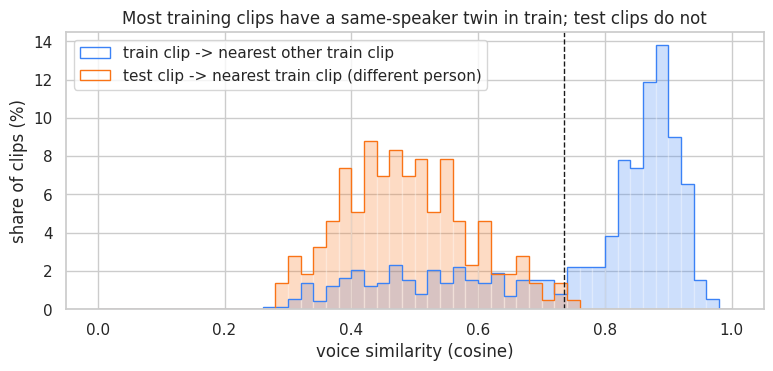

In [11]:
assert wavlm_out is not None, "WavLM features are needed to group clips by speaker - re-run the WavLM cell (see the [skip] message above)"
voice = wavlm_out[1].astype(np.float32)
voice = (voice - voice.mean(0)) / (voice.std(0) + 1e-6); voice /= np.linalg.norm(voice, axis=1, keepdims=True)    # unit length -> dot product = cosine

sim_tr = voice[:N_TRAIN] @ voice[:N_TRAIN].T; np.fill_diagonal(sim_tr, -1)
nearest_cross = (voice[N_TRAIN:] @ voice[:N_TRAIN].T).max(1)          # most similar training clip, for every test clip (a different person)
nearest_train = sim_tr.max(1)                                          # most similar other training clip
SAME_SPK = float(np.percentile(nearest_cross, 99.5))
_, spk_train = connected_components(sim_tr > SAME_SPK, directed=False)
sim_te = voice[N_TRAIN:] @ voice[N_TRAIN:].T; np.fill_diagonal(sim_te, -1)
_, spk_test = connected_components(sim_te > SAME_SPK, directed=False)
spk = spk_train[graded]                                                # speaker of every clip used for training / CV

sz = pd.Series(spk).value_counts(); sz_te = pd.Series(spk_test).value_counts()
print(f"same-speaker threshold (cosine) = {SAME_SPK:.3f}")
print(f"train: {len(sz)} speakers among {graded.sum()} scored clips | clips per speaker: " + ", ".join(f"{k}: {v}" for k, v in sz.value_counts().sort_index().items()))
print(f"test : {len(sz_te)} speakers among {N - N_TRAIN} clips | clips per speaker: " + ", ".join(f"{k}: {v}" for k, v in sz_te.value_counts().sort_index().items()))
print(f"largest train group: {sz.max()} clips | test clips that share a speaker with another test clip: {(pd.Series(spk_test).map(sz_te) > 1).sum()}")
within = pd.DataFrame({"spk": spk, "y": y}).groupby("spk").y.std().dropna().mean()
print(f"score spread: {y.std():.2f} over all clips vs {within:.2f} between clips of the same speaker  -> a speaker's clips get almost the same score")

bins = np.linspace(0.0, 1.0, 51); fig, ax = plt.subplots(figsize=(9, 3.6))
for v, c, l in ((nearest_train[graded], "#3b82f6", "train clip -> nearest other train clip"), (nearest_cross, "#f97316", "test clip -> nearest train clip (different person)")):
    ax.hist(v, bins=bins, weights=np.full(len(v), 100 / len(v)), color=c, alpha=.25); ax.hist(v, bins=bins, weights=np.full(len(v), 100 / len(v)), color=c, histtype="step", lw=2, label=l)
ax.axvline(SAME_SPK, color="k", ls="--", lw=1); ax.set(xlabel="voice similarity (cosine)", ylabel="share of clips (%)", title="Most training clips have a same-speaker twin in train; test clips do not"); ax.legend(loc="upper left"); plt.show()

## 6. Modelling & Validation

The dataset is small relative to the dimensionality of the pretrained representations. Fine-tuning large neural networks would therefore create a high risk of overfitting.

Instead, the neural networks remain frozen and the final prediction layers are deliberately simple:

- **Ridge regression** for high-dimensional approximately linear relationships
- **RBF-SVR** for nonlinear relationships
- **LightGBM** for heterogeneous handcrafted features
- **Non-negative stacking** to combine complementary predictors

The objective is not to find one universally best representation, but to combine representations that make different errors.

In [12]:
strat   = np.round(y).astype(int)
SPLITS  = [list(StratifiedGroupKFold(N_FOLDS, shuffle=True, random_state=SEED + r).split(y, strat, spk)) for r in range(CV_REPEATS)]
from sklearn.model_selection import StratifiedKFold
RSPLITS = [list(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED + r).split(y, strat)) for r in range(CV_REPEATS)]   # random folds - only to show how misleading they are
print("validation clips whose speaker also appears in the training folds: "
      f"{np.mean([np.isin(spk[b], spk[a]).mean() for a, b in SPLITS[0]]):.0%} with speaker folds vs {np.mean([np.isin(spk[b], spk[a]).mean() for a, b in RSPLITS[0]]):.0%} with random folds")

clipp = lambda p: np.clip(p, 1, 5)
def make_ridge(alpha): return make_pipeline(StandardScaler(), Ridge(alpha=alpha))
def make_svr(C):       return make_pipeline(StandardScaler(), SVR(kernel="rbf", C=C, epsilon=0.1, gamma="scale"))
def make_gbm():        return lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, num_leaves=6, min_child_samples=15, subsample=0.8, subsample_freq=1,
                                                colsample_bytree=0.7, reg_lambda=2.0, random_state=SEED, verbose=-1, n_jobs=1)

def design(views, rows): return np.hstack([VIEWS[v][rows] for v in views])

def _fit_pred(make_model, X, yy, a, b, Xte):
    m = make_model().fit(X[a], yy[a]); return m.predict(X[b]), (m.predict(Xte) if Xte is not None else None)

def run_oof(make_model, X, Xte, splits):
    """Out-of-fold predictions (repeats x clips) and the fold-averaged test prediction."""
    jobs = [(r, a, b) for r, sp in enumerate(splits) for a, b in sp]
    outs = Parallel(n_jobs=N_JOBS)(delayed(_fit_pred)(make_model, X, y, a, b, Xte) for _, a, b in jobs)
    oof, te = np.zeros((len(splits), len(y))), []
    for (r, a, b), (pb, pt) in zip(jobs, outs):
        oof[r, b] = pb
        if pt is not None: te.append(pt)
    return oof, (np.mean(te, 0) if te else None)

ALPHAS = np.logspace(1, 6, 21)
def ridge_scan(X, yy, splits, alphas=ALPHAS):
    """Cross-validated MSE of ridge for every alpha, in closed form (dual form + one eigendecomposition per fold)."""
    mse, cnt = np.zeros(len(alphas)), 0
    for sp in splits:
        for a, b in sp:
            mu, sd = X[a].mean(0), X[a].std(0) + 1e-8
            Xa, Xb = (X[a] - mu) / sd, (X[b] - mu) / sd
            lam, V = np.linalg.eigh(Xa @ Xa.T); Kb = Xb @ Xa.T; ym = yy[a].mean(); Vty = V.T @ (yy[a] - ym)
            for k, al in enumerate(alphas): mse[k] += np.mean((yy[b] - clipp(ym + Kb @ (V @ (Vty / (lam + al))))) ** 2)
            cnt += 1
    return mse / cnt

SVR_CS = [1.0, 3.0, 10.0]
BASE = {}
def fit_spec(learner, views):
    name = "+".join(views) + " | " + learner
    if name in BASE: return BASE[name]
    X, Xte = design(views, rows_g), design(views, rows_test)
    if learner == "ridge":
        a = float(ALPHAS[int(np.argmin(ridge_scan(X, y, SPLITS[:1])))]); mk, info = partial(make_ridge, a), f"alpha={a:.0f}"
    elif learner == "svr":
        sc = {C: rmse(y, clipp(run_oof(partial(make_svr, C), X, None, SPLITS[:1])[0][0])) for C in SVR_CS}
        C = min(sc, key=sc.get); mk, info = partial(make_svr, C), f"C={C:g}"
    else: mk, info = make_gbm, ""
    oof, te = run_oof(mk, X, Xte, SPLITS); full = mk().fit(X, y)
    BASE[name] = dict(name=name, learner=learner, views=views, info=info, oof=oof, test=te, train_in=full.predict(X), test_full=full.predict(Xte),
                      rmse=float(np.mean([rmse(y, clipp(o)) for o in oof])))
    return BASE[name]

def family_of_view(v):
    if v.startswith(("whisper", "wavlm")): return "audio"
    if v.startswith(("roberta", "electra", "deberta")): return "text"
    if v.startswith(("qwen", "phi")): return "llm"
    return "features"
def family(name):
    fams = {family_of_view(v) for v in name.split(" | ")[0].split("+")}
    return "fusion" if len(fams) > 1 else fams.pop()

validation clips whose speaker also appears in the training folds: 0% with speaker folds vs 63% with random folds


ridge on every layer:   0%|          | 0/41 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/v

SVR on the best layers:   0%|          | 0/14 [00:00<?, ?it/s]

fusion SVR:   0%|          | 0/9 [00:00<?, ?it/s]

69 base models fitted in 409s


,model,family,rmse,info
0,whisper32+wavlm21+deberta24+phi_pool16 | ridge,fusion,0.528,alpha=10000
1,whisper32+deberta24+feats | ridge,fusion,0.532,alpha=5623
2,whisper32+deberta24+phi_pool16 | ridge,fusion,0.532,alpha=5623
3,whisper32+deberta24 | svr,fusion,0.538,C=3
4,whisper32+deberta24+feats | svr,fusion,0.538,C=3
5,whisper32+wavlm21+deberta24+phi_pool16 | svr,fusion,0.538,C=3
6,whisper32+deberta24+deberta20+phi_pool16+feats...,fusion,0.541,C=3
7,whisper32+deberta24+phi_pool16+feats | svr,fusion,0.543,C=3
8,whisper32+deberta24+phi_pool16 | svr,fusion,0.543,C=3
9,whisper32+phi_pool16 | svr,fusion,0.550,C=3


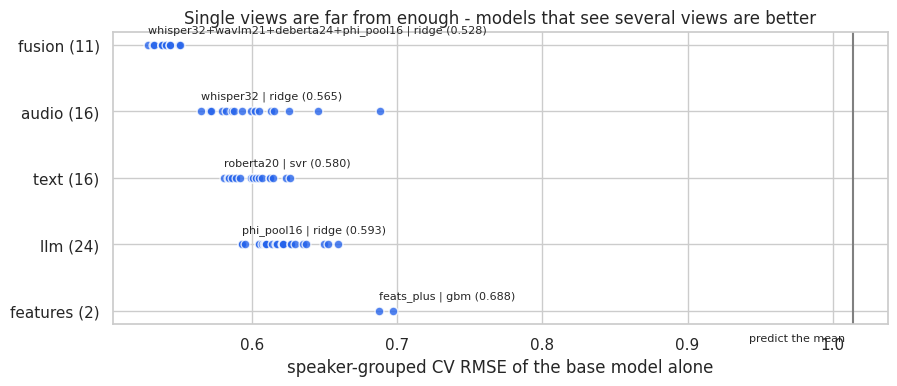

,speaker-grouped folds,random folds
whisper32 | ridge,0.565000,0.546000
wavlm21 | ridge,0.582000,0.544000
deberta24 | ridge,0.584000,0.577000
phi_pool16 | ridge,0.593000,0.587000


In [13]:
t0 = time.time()
singles = [v for v in VIEWS if v not in ("feats", "feats_plus") and not v.endswith("_mid")]
for v in tqdm(singles, desc="ridge on every layer"): fit_spec("ridge", (v,))
for v in ("feats", "feats_plus"): fit_spec("gbm", (v,))

solo_ridge = {v: BASE[f"{v} | ridge"]["rmse"] for v in singles}
def top_views(prefixes, k):
    c = sorted([v for v in singles if v.startswith(prefixes)], key=solo_ridge.get); return c[:k]

# SVR on the two best layers of every network family
svr_views = sum([top_views(p, 2) for p in ("whisper", "wavlm", "roberta", "electra", "deberta", "qwen", "phi")], [])
for v in tqdm(svr_views, desc="SVR on the best layers"): fit_spec("svr", (v,))

# fusion models: concatenate the best view of each kind (chosen from the single-view results above)
b_whisper, b_wavlm = (top_views("whisper", 1) or [None])[0], (top_views("wavlm", 1) or [None])[0]
b_text = (top_views(("roberta", "electra", "deberta"), 1) or [None])[0]; b_llm = (top_views(("qwen", "phi"), 1) or [None])[0]
b_text2 = (top_views(("roberta", "electra", "deberta"), 2) or [None, None])[-1]
fusions = [(b_whisper, b_text, "feats"), (b_whisper, b_text, b_llm), (b_whisper, b_wavlm, b_text, b_llm), (b_whisper, b_llm), (b_whisper, b_text, b_llm, "feats"),
           (b_whisper, b_wavlm), (b_whisper, b_text), (b_whisper, b_text, b_text2, b_llm, "feats"), (b_wavlm, b_text, b_llm)]
fusions = list(dict.fromkeys(tuple(dict.fromkeys(f)) for f in fusions if all(v is not None for v in f) and len(set(f)) > 1))
for f in tqdm(fusions, desc="fusion SVR"): fit_spec("svr", f)
for f in fusions[:3]: fit_spec("ridge", f)
print(f"{len(BASE)} base models fitted in {time.time() - t0:.0f}s")

solo = pd.DataFrame([dict(model=n, family=family(n), rmse=b["rmse"], info=b["info"]) for n, b in BASE.items()]).sort_values("rmse").reset_index(drop=True)
display(solo.head(12).round(3))

fam_order = ["fusion", "audio", "text", "llm", "features"]
fig, ax = plt.subplots(figsize=(10, 3.8))
for fi, fam in enumerate(fam_order):
    d = solo[solo.family == fam]
    if not len(d): continue
    ax.scatter(d.rmse, np.full(len(d), fi), s=40, color="#2563eb", alpha=.8, edgecolor="white")
    b = d.iloc[0]; ax.annotate(f"{b.model} ({b.rmse:.3f})", (b.rmse, fi), xytext=(0, 9), textcoords="offset points", fontsize=8)
ax.axvline(y.std(), color="gray"); ax.text(y.std() - .005, len(fam_order) - .55, "predict the mean", ha="right", fontsize=8)
ax.set_yticks(range(len(fam_order))); ax.set_yticklabels([f"{f} ({(solo.family == f).sum()})" for f in fam_order]); ax.invert_yaxis()
ax.set_xlabel("speaker-grouped CV RMSE of the base model alone"); ax.set_title("Single views are far from enough - models that see several views are better"); plt.show()

# how misleading are random folds?  (same model, same alpha; only the folds differ)
demo = [(v,) for v in dict.fromkeys([b_whisper, b_wavlm, b_text, b_llm]) if v]
tab = {}
for (v,) in demo:
    X = design((v,), rows_g); a = float(ALPHAS[int(np.argmin(ridge_scan(X, y, SPLITS[:1])))])
    tab[f"{v} | ridge"] = {"speaker-grouped folds": BASE[f"{v} | ridge"]["rmse"], "random folds": float(np.mean([rmse(y, clipp(o)) for o in run_oof(partial(make_ridge, a), X, None, RSPLITS)[0]]))}
display(pd.DataFrame(tab).T.round(3).style.set_caption("Audio models look better when a speaker's other clips sit in the training fold - hence grouped validation"))

### 6.1 Non-negative Stacking

The individual regressors are deliberately treated as **candidate views of the same underlying signal**.

Their out-of-fold predictions are combined using non-negative least squares with a free intercept:

\[
\hat{y} = b + \sum_i w_i \hat{y}_i,
\qquad w_i \geq 0
\]

Non-negative weights make the final ensemble easier to interpret: the stack can emphasize useful models without creating unstable cancellation between strongly correlated predictors.

A small shrinkage term is also used for the wider stack, discouraging extreme concentration on a single model.

wide stack: 51 models (37 carry weight) | top stack: 10 models (4 carry weight)


,RMSE,Pearson,MSE
Predict the mean,1.013700,nan,1.027600
Best single base model,0.528200,0.855400,0.279000
Best fusion model,0.528200,0.855400,0.279000
Wide stack,0.509800,0.864700,0.259900
Top stack,0.520500,0.858500,0.270900
Average of the two stacks,0.512100,0.863400,0.262300
+ speaker pooling (FINAL),0.508800,0.865800,0.258900


speaker pooling, RMSE on clips of speakers with several clips: lambda=0: 0.4980, lambda=0.25: 0.4930, lambda=0.5: 0.4931, lambda=0.75: 0.4981, lambda=1.0: 0.5080


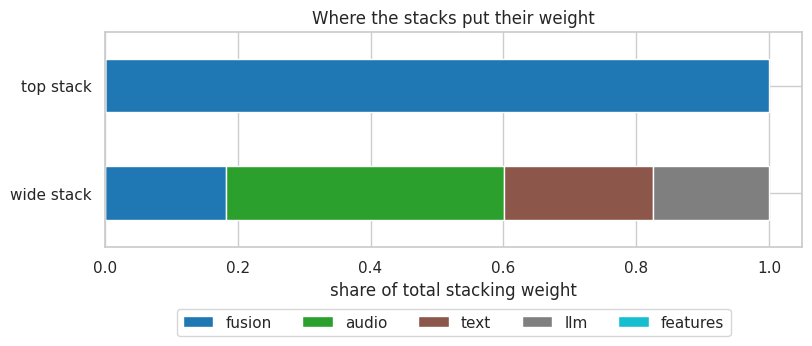

In [14]:
def nnls_weights(A, target, shrink=0.0):
    """Non-negative weights + free intercept. shrink > 0 adds an L2 pull of the weights towards 1/k each."""
    mu, tb = A.mean(0), target.mean(); k = A.shape[1]
    if shrink:
        s = np.sqrt(shrink * len(target)); w, _ = nnls(np.vstack([A - mu, s * np.eye(k)]), np.r_[target - tb, s * np.ones(k) / k])
    else: w, _ = nnls(A - mu, target - tb)
    return w, mu, tb

def build_stack(names, shrink):
    A = np.stack([BASE[n]["oof"] for n in names], 2)                                    # repeats x clips x models
    cf = np.zeros(A.shape[:2])                                                           # cross-fitted out-of-fold stack predictions
    for r, sp in enumerate(SPLITS):
        for a, b in sp:
            w, mu, tb = nnls_weights(A[r][a], y[a], shrink); cf[r, b] = tb + (A[r][b] - mu) @ w
    w, mu, tb = nnls_weights(A.mean(0), y, shrink)                                       # final weights: fitted on repeat-averaged OOF predictions
    cols = lambda key: np.column_stack([BASE[n][key] for n in names])
    return dict(names=names, w=w, oof=cf, train_in=tb + (cols("train_in") - mu) @ w, test=tb + (cols("test") - mu) @ w)

best = solo.rmse.min()
wide_names = list(solo.model[solo.rmse <= best + 0.09]); top_names = list(solo.model[:10])
S_WIDE, S_TOP = build_stack(wide_names, STACK_SHRINK), build_stack(top_names, 0.0)
print(f"wide stack: {len(wide_names)} models ({int((S_WIDE['w'] > 0.002).sum())} carry weight) | top stack: {len(top_names)} models ({int((S_TOP['w'] > 0.002).sum())} carry weight)")

def pool_speaker(p, groups, lam=POOL_LAMBDA):
    """Move each prediction a fraction lam towards the mean prediction of the same speaker's clips (in the set being scored)."""
    return p + lam * (pd.Series(p).groupby(groups).transform("mean").values - p)

def scores(P, mask=None):
    P = np.atleast_2d(clipp(P)); m = np.ones(len(y), bool) if mask is None else mask
    return dict(RMSE=float(np.mean([rmse(y[m], p[m]) for p in P])), Pearson=float(np.mean([pearsonr(y[m], p[m])[0] for p in P])))

FINAL_OOF = (S_WIDE["oof"] + S_TOP["oof"]) / 2
POOLED_OOF = np.stack([pool_speaker(p, spk) for p in FINAL_OOF])
rows = [("Predict the mean", dict(RMSE=float(y.std()), Pearson=np.nan)), ("Best single base model", scores(BASE[solo.model[0]]["oof"])),
        ("Best fusion model", scores(BASE[solo.model[solo.family == "fusion"].iloc[0]]["oof"])) if (solo.family == "fusion").any() else None,
        ("Wide stack", scores(S_WIDE["oof"])), ("Top stack", scores(S_TOP["oof"])), ("Average of the two stacks", scores(FINAL_OOF)), ("+ speaker pooling  (FINAL)", scores(POOLED_OOF))]
CV_TABLE = pd.DataFrame({k: v for k, v in rows if k}).T; CV_TABLE["MSE"] = CV_TABLE.RMSE ** 2
display(CV_TABLE.round(4).style.set_caption("Speaker-grouped cross-validation on the 732 scored clips (the leaderboard score behaves like the MSE column)"))

size = pd.Series(spk).map(pd.Series(spk).value_counts()).values
print("speaker pooling, RMSE on clips of speakers with several clips: " + ", ".join(f"lambda={l}: {scores(np.stack([pool_speaker(p, spk, l) for p in FINAL_OOF]), size > 1)['RMSE']:.4f}" for l in (0, .25, .5, .75, 1.0)))

# --- stack weights by family
wf = pd.DataFrame({nm: pd.Series(s["w"], index=[family(n) for n in s["names"]]).groupby(level=0).sum() for nm, s in (("wide stack", S_WIDE), ("top stack", S_TOP))}).reindex(fam_order).fillna(0)
wf = wf / wf.sum(); ax = wf.T.plot.barh(stacked=True, figsize=(9, 2.8), colormap="tab10"); ax.set_xlabel("share of total stacking weight"); ax.set_title("Where the stacks put their weight"); ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(.5, -.25)); plt.show()

## 7. Evaluation, error analysis & interpretability
The **training RMSE** (compulsory) is the error of the fitted pipeline on the clips it was fitted on – all base models are re-fitted on every scored clip, the stack weights are applied, predictions are pooled within training speakers and clipped, and the noise guard sets the label-0 clips to 0. It is optimistic by construction. The **speaker-grouped cross-validated** numbers are the honest estimate for new speakers.

In [15]:
tr_in      = pool_speaker((S_WIDE["train_in"] + S_TOP["train_in"]) / 2, spk)
pred_g_in  = clipp(tr_in)
pred_all   = np.zeros(N_TRAIN); pred_all[graded] = pred_g_in                          # noise-guard clips keep the score 0
TRAIN_RMSE, TRAIN_R         = rmse(y_all, pred_all), pearsonr(y_all, pred_all)[0]
TRAIN_RMSE_CLEAN, TRAIN_R_C = rmse(y, pred_g_in), pearsonr(y, pred_g_in)[0]
cv_s        = scores(POOLED_OOF); CV_RMSE, CV_R = cv_s["RMSE"], cv_s["Pearson"]
oof_all     = np.zeros((CV_REPEATS, N_TRAIN)); oof_all[:, graded] = clipp(POOLED_OOF)
CV_RMSE_ALL = float(np.mean([rmse(y_all, o) for o in oof_all]))

display(Markdown(f"""
| Evaluation | RMSE | MSE | Pearson r |
|---|---|---|---|
| **Training set, in-sample, all {N_TRAIN} clips - the compulsory training RMSE** | **{TRAIN_RMSE:.4f}** | {TRAIN_RMSE ** 2:.4f} | {TRAIN_R:.4f} |
| Training set, in-sample, {graded.sum()} scored clips | {TRAIN_RMSE_CLEAN:.4f} | {TRAIN_RMSE_CLEAN ** 2:.4f} | {TRAIN_R_C:.4f} |
| **Speaker-grouped cross-validation, {graded.sum()} scored clips** - expected for new speakers | **{CV_RMSE:.4f}** | **{CV_RMSE ** 2:.4f}** | {CV_R:.4f} |
| Speaker-grouped cross-validation, all {N_TRAIN} clips (noise guard included) | {CV_RMSE_ALL:.4f} | {CV_RMSE_ALL ** 2:.4f} | {np.mean([pearsonr(y_all, o)[0] for o in oof_all]):.4f} |
| Baseline: predict the mean, scored clips | {y.std():.4f} | {y.std() ** 2:.4f} | - |

The in-sample figure only shows how closely the models fit; **the cross-validated MSE is the number to compare with the leaderboard** (test clips come from new speakers *and* a different prompt mix, so the leaderboard error is typically somewhat above the cross-validated one).
"""))
print(f"TRAINING RMSE = {TRAIN_RMSE:.4f}")


| Evaluation | RMSE | MSE | Pearson r |
|---|---|---|---|
| **Training set, in-sample, all 769 clips - the compulsory training RMSE** | **0.2505** | 0.0627 | 0.9797 |
| Training set, in-sample, 732 scored clips | 0.2567 | 0.0659 | 0.9681 |
| **Speaker-grouped cross-validation, 732 scored clips** - expected for new speakers | **0.5088** | **0.2589** | 0.8658 |
| Speaker-grouped cross-validation, all 769 clips (noise guard included) | 0.4965 | 0.2465 | 0.9164 |
| Baseline: predict the mean, scored clips | 1.0137 | 1.0276 | - |

The in-sample figure only shows how closely the models fit; **the cross-validated MSE is the number to compare with the leaderboard** (test clips come from new speakers *and* a different prompt mix, so the leaderboard error is typically somewhat above the cross-validated one).


TRAINING RMSE = 0.2505


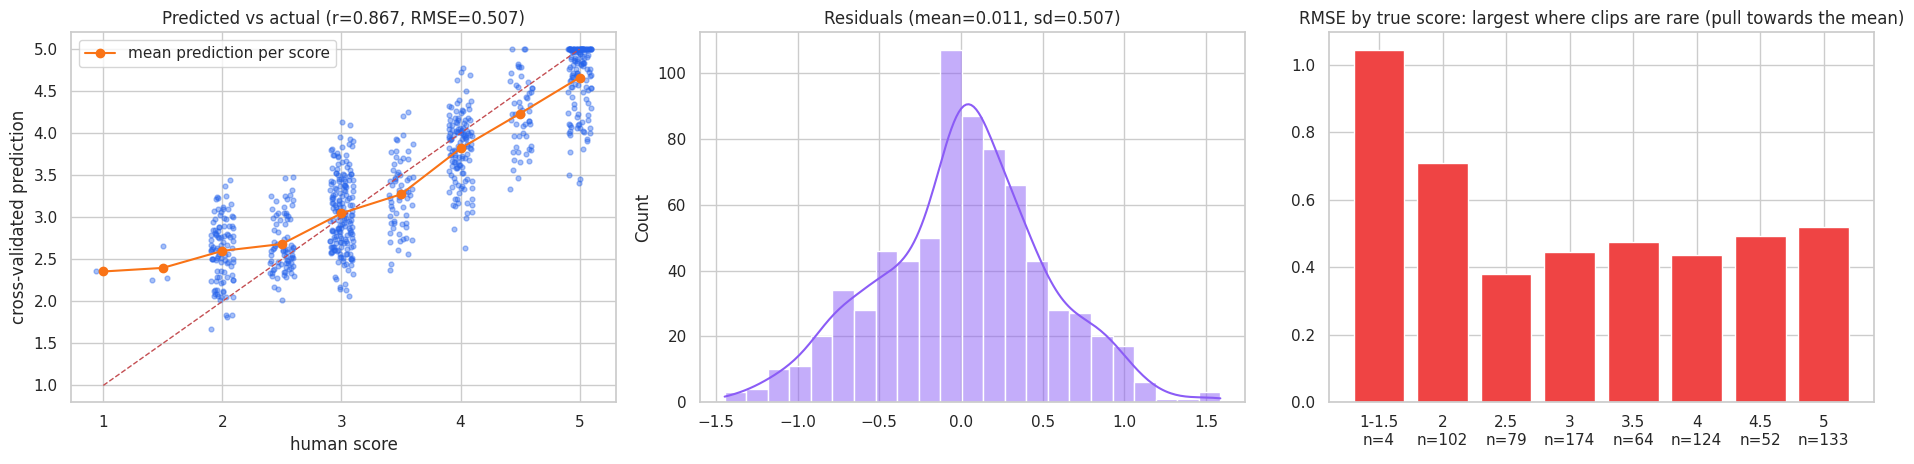

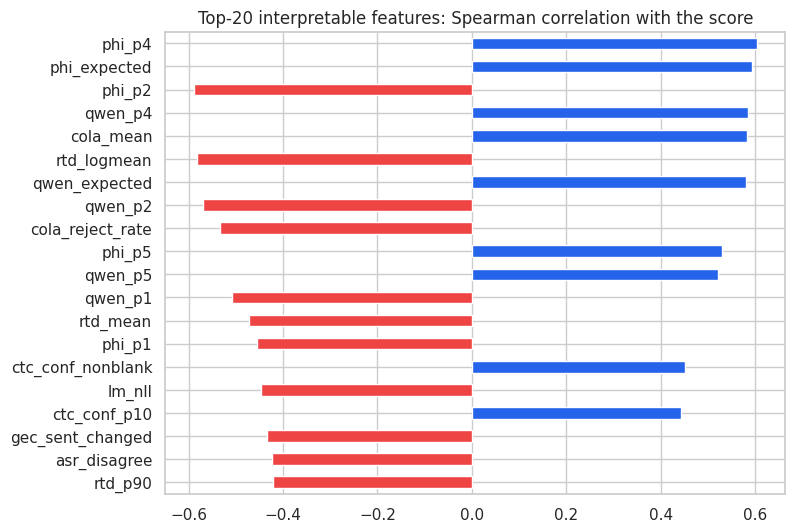

audio_108.wav | TRUE=1.0 | PRED=2.36
TRANSCRIPT: As a young child, one of the most exacting place to be was the playground. It was a place with the rules of classrooms and the structure environment of schools has been played well in our life. The school days, we need to play a very good sport in our playgrounds and we are lots of injuries in that our school time. So at the time, played a lot of things even we have got injuries in that so we will get selected for th
audio_581.wav | TRUE=1.5 | PRED=2.28
TRANSCRIPT: My goal is to become an electrical employee and also I'm studying the electrical electronics engineering to become an electrical engineer. I have to study about electrical and to achieve my goal is to have a about the electronics and we have prepared the topics thoroughly to reach the goals.
audio_417.wav | TRUE=3.5 | PRED=2.89
TRANSCRIPT: I want to describe a scene which was done in my school playground is, that is the cricket match between the 10th class students and 9th cla

In [16]:
p = clipp(POOLED_OOF[0]); res = y - p; levels = np.sort(np.unique(y))
fig, ax = plt.subplots(1, 3, figsize=(19, 4.8)); jit = np.random.RandomState(0).uniform(-.1, .1, len(y))
ax[0].scatter(y + jit, p, s=12, alpha=.4, c="#2563eb"); ax[0].plot([1, 5], [1, 5], "r--", lw=1); ax[0].plot(levels, [p[y == l].mean() for l in levels], "o-", c="#f97316", label="mean prediction per score"); ax[0].legend()
ax[0].set(xlabel="human score", ylabel="cross-validated prediction", title=f"Predicted vs actual (r={pearsonr(y, p)[0]:.3f}, RMSE={rmse(y, p):.3f})")
sns.histplot(res, kde=True, ax=ax[1], color="#8b5cf6"); ax[1].set_title(f"Residuals (mean={res.mean():.3f}, sd={res.std():.3f})")
bands = [("1-1.5", y <= 1.5), ("2", y == 2), ("2.5", y == 2.5), ("3", y == 3), ("3.5", y == 3.5), ("4", y == 4), ("4.5", y == 4.5), ("5", y == 5)]
bd = pd.DataFrame([(n, int(m.sum()), rmse(y[m], p[m])) for n, m in bands if m.sum()], columns=["score", "n", "RMSE"])
ax[2].bar(bd.score + "\nn=" + bd.n.astype(str), bd.RMSE, color="#ef4444"); ax[2].set_title("RMSE by true score: largest where clips are rare (pull towards the mean)"); plt.tight_layout(); plt.show()

# --- which interpretable features track the score?
cor = pd.Series({c: spearmanr(FEATS_PLUS[c].values[rows_g], y)[0] for c in FEATS_PLUS.columns}).dropna().sort_values(key=np.abs, ascending=False).head(20)
fig, ax = plt.subplots(figsize=(8, 6)); cor[::-1].plot.barh(ax=ax, color=["#ef4444" if v < 0 else "#2563eb" for v in cor[::-1]]); ax.set_title("Top-20 interpretable features: Spearman correlation with the score"); plt.show()

# --- qualitative: transcript + corrections for the lowest / median / highest scored clips
order = np.argsort(y); pick = list(order[:2]) + [order[len(order) // 2]] + list(order[-2:])
for j in pick:
    i = rows_g[j]; print("=" * 110); print(f"{meta.filename[i]} | TRUE={y[j]} | PRED={p[j]:.2f}"); print("TRANSCRIPT:", texts[i][:420])
    if gec_sents is not None:
        for _, r in gec_sents[(gec_sents.clip == i) & (gec_sents.edits > 0)].head(2).iterrows(): print(f"   corrector: '{r.sentence[:90]}'  ->  '{r.corrected[:90]}'")

## 8. Final Test Predictions

After model selection and validation, the complete training set is used to fit the base regressors.

For each test clip:

1. Neural and linguistic representations are loaded from the cache.
2. Base regressors produce predictions.
3. The wide and top-performing stacks are combined.
4. Predictions for repeated test speakers are partially pooled.
5. Predictions are constrained to the valid grammar-score range.
6. The noise guard is applied as a final safety rule.
7. The submission is written in the exact order of `test.csv`.

No test labels are used at any stage.

test: 216 clips | noise-guard zeros: 0 | clips sharing a speaker with another test clip (pooled): 54
predictions: min 1.75  mean 3.27  max 5.00  (train labels 1-5: mean 3.48)

ID audit: test.csv 216 rows | sample_submission 204 rows | shared IDs: 25 -> the submission follows test.csv
saved /kaggle/working/submission.csv  shape=(216, 2)


,filename,label
0,audio_128.wav,3.1100
1,audio_156.wav,3.9882
2,audio_19.wav,4.5208
3,audio_108.wav,2.0724
4,audio_206.wav,1.9033


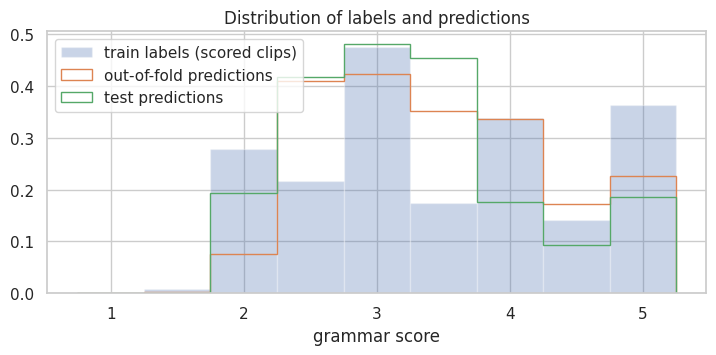

In [17]:
te_raw     = (S_WIDE["test"] + S_TOP["test"]) / 2
final_test = clipp(pool_speaker(te_raw, spk_test)); final_test[is_noise[N_TRAIN:]] = 0.0
print(f"test: {len(final_test)} clips | noise-guard zeros: {(final_test == 0).sum()} | clips sharing a speaker with another test clip (pooled): {(pd.Series(spk_test).map(pd.Series(spk_test).value_counts()) > 1).sum()}")
print(f"predictions: min {final_test.min():.2f}  mean {final_test.mean():.2f}  max {final_test.max():.2f}  (train labels 1-5: mean {y.mean():.2f})")

# ---- ID audit: test.csv vs the (inconsistent) sample_submission.csv
norm = lambda s: os.path.splitext(os.path.basename(str(s)))[0].strip().lower()
key, tgt = sample_sub.columns[0], sample_sub.columns[1]
ids_test, ids_sample = set(map(norm, test_df.filename)), set(map(norm, sample_sub[key]))
print(f"\nID audit: test.csv {len(test_df)} rows | sample_submission {len(sample_sub)} rows | shared IDs: {len(ids_test & ids_sample)} -> the submission follows test.csv")

assert len(final_test) == len(test_df) and np.isfinite(final_test).all() and ((final_test >= 0) & (final_test <= 5)).all()
sub = pd.DataFrame({key: test_df.filename.astype(str).values, tgt: np.round(final_test, 4)}); assert sub[key].is_unique
sub.to_csv(OUT_DIR / "submission.csv", index=False)
solo.to_csv(OUT_DIR / "base_model_scores.csv", index=False); CV_TABLE.to_csv(OUT_DIR / "cv_table.csv")
pd.DataFrame({"filename": train_df.filename[graded].values, "label": y, "oof_pred": clipp(POOLED_OOF).mean(0)}).to_csv(OUT_DIR / "oof_predictions.csv", index=False)
print(f"saved {OUT_DIR / 'submission.csv'}  shape={sub.shape}"); display(sub.head())

fig, ax = plt.subplots(figsize=(8.5, 3.4)); bins = np.arange(0.75, 5.5, 0.5)
ax.hist(y, bins=bins, density=True, alpha=.3, label="train labels (scored clips)"); ax.hist(clipp(POOLED_OOF[0]), bins=bins, density=True, histtype="step", lw=2, label="out-of-fold predictions")
ax.hist(final_test, bins=bins, density=True, histtype="step", lw=2, label="test predictions"); ax.legend(); ax.set_xlabel("grammar score"); ax.set_title("Distribution of labels and predictions"); plt.show()

## 9. Conclusion

This solution treats spoken grammar assessment as a **multimodal prediction problem**.

Rather than fine-tuning a large model on a small dataset, pretrained models are frozen and used to provide complementary representations:

- **Acoustic:** Whisper and WavLM
- **Linguistic:** RoBERTa, DeBERTa and ELECTRA
- **Examiner-style reasoning:** Qwen2.5-3B and Phi-3.5-mini
- **Explicit grammar:** CoLA, T5 GEC, ELECTRA token anomaly, GPT-2 surprisal and syntactic statistics
- **Speaker structure:** WavLM-based speaker grouping

The final prediction is produced through regularised regressors and non-negative stacking, with speaker-aware validation and test-time pooling.

### Key lessons

1. **Validation matters as much as modelling.** Random folds can substantially overestimate performance when speakers repeat.
2. **Grammar is not purely acoustic.** Transcript and linguistic features provide information that acoustic embeddings cannot capture alone.
3. **Different pretrained models encode different useful views.** Combining complementary representations is more effective than relying on one large model.
4. **Small datasets favour frozen representations and regularised heads.** Fine-tuning large networks would introduce considerably more parameters than the dataset can reliably support.
5. **Competition-specific structure can matter.** Speaker repetition, corrupted recordings and the train/test distribution were all incorporated into the final pipeline.